In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("crime-housing-austin-2015.csv")
print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 38573
Columns: 43


,Key,Council_District,Highest_Offense_Desc,Highest_NIBRS_UCR_Offense_Description,Report_Date,Location,Clearance_Status,Clearance_Date,District,Zip_Code_Crime,...,Rentalunitsaffordabletoaverageteacher,Ownerunitsaffordabletoaverageteacher,Rentalunitsaffordabletoaveragetechworker,Ownerunitsaffordabletoaveragetechworker,Changeinpercentageofpopulationbelowpoverty2000-2012,Changeinmedianrent2000-2012,Changeinmedianhomevalue2000-2012,Percentageofhomeswithin1/4-mioftransitstop,Averagemonthlytransportationcost,Percentageofhousingandtransportationcoststhatistransportation-related
0,201510782,4.0,AGG ROBBERY/DEADLY WEAPON,Robbery,1-Jan-15,9001 N IH 35 SVRD NB,N,28-Jan-15,E,78753.0,...,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
1,201511231,4.0,ROBBERY BY ASSAULT,Robbery,1-Jan-15,919 E KOENIG LN SVRD EB,N,13-Jan-15,I,78751.0,...,68%,10%,97%,42%,23%,38%,97%,98%,$550,40%
2,201511736,1.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,12151 N IH 35 SVRD NB,N,13-Jan-15,E,78753.0,...,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
3,201511433,4.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,1044 NORWOOD PARK BLVD,N,5-Jan-15,I,78753.0,...,89%,75%,100%,98%,128%,26%,40%,59%,$708,44%
4,201511936,2.0,BURGLARY OF RESIDENCE,Burglary,1-Jan-15,2413 BITTER CREEK DR,N,7-Jan-15,F,78744.0,...,81%,87%,100%,100%,89%,26%,44%,63%,$708,40%


In [3]:
print(df.columns.tolist())
df.isnull().sum().sort_values(ascending=False).head(15)

['Key', 'Council_District', 'Highest_Offense_Desc', 'Highest_NIBRS_UCR_Offense_Description', 'Report_Date', 'Location', 'Clearance_Status', 'Clearance_Date', 'District', 'Zip_Code_Crime', 'Census_Tract', 'X_Coordinate', 'Y_Coordinate', 'Zip_Code_Housing', 'Populationbelowpovertylevel', 'Medianhouseholdincome', 'Non-WhiteNon-HispanicorLatino', 'HispanicorLatinoofanyrace', 'Populationwithdisability', 'Unemployment', 'Largehouseholds(5+members)', 'Homesaffordabletopeopleearninglessthan$50000', 'Rentalsaffordabletopeopleearninglessthan$25000', 'Rent-restrictedunits', 'HousingChoiceVoucherholders', 'Medianrent', 'Medianhomevalue', 'Percentageofrentalunitsinpoorcondition', 'Percentchangeinnumberofhousingunits2000-2012', 'Ownerunitsaffordabletoaverageretail/serviceworker', 'Rentalunitsaffordabletoaverageretail/serviceworker', 'Rentalunitsaffordabletoaverageartist', 'Ownerunitsaffordabletoaverageartist', 'Rentalunitsaffordabletoaverageteacher', 'Ownerunitsaffordabletoaverageteacher', 'Rentalun

Clearance_Status                                     1924
Clearance_Date                                       1924
Homesaffordabletopeopleearninglessthan$50000         1405
Ownerunitsaffordabletoaverageretail/serviceworker    1405
Ownerunitsaffordabletoaverageartist                  1405
Ownerunitsaffordabletoaverageteacher                 1405
Ownerunitsaffordabletoaveragetechworker              1405
Zip_Code_Housing                                     1288
Non-WhiteNon-HispanicorLatino                        1129
Populationbelowpovertylevel                          1129
Rent-restrictedunits                                 1129
Rentalunitsaffordabletoaverageteacher                1129
Rentalunitsaffordabletoaveragetechworker             1129
Medianhomevalue                                      1129
Medianrent                                           1129
dtype: int64

In [4]:
def clean_numeric(series):
    """
    Remove $, %, and commas and convert values to numeric.
    Invalid/missing values become NaN.
    """
    return pd.to_numeric(
        series.astype("string")
            .str.replace("$", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip(),
        errors="coerce"
    )

numeric_housing_columns = [
    "Populationbelowpovertylevel",
    "Medianhouseholdincome",
    "Medianrent",
    "Medianhomevalue",
    "Homesaffordabletopeopleearninglessthan$50000",
    "Rentalsaffordabletopeopleearninglessthan$25000",
    "Ownerunitsaffordabletoaverageretail/serviceworker",
    "Rentalunitsaffordabletoaverageretail/serviceworker",
]

for column in numeric_housing_columns:
    df[column] = clean_numeric(df[column])

df[numeric_housing_columns].head()

,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker
0,26,39593,826,134900,78,14,8,11
1,26,38624,865,292200,11,13,0,9
2,26,39593,826,134900,78,14,8,11
3,26,39593,826,134900,78,14,8,11
4,26,41056,946,108100,93,7,13,6


In [5]:
crime_counts = (
    df.dropna(subset=["Zip_Code_Housing"])
      .groupby("Zip_Code_Housing")
      .size()
      .rename("Crime_Count")
)

crime_counts.head()

Zip_Code_Housing
78617.0     276
78701.0    2103
78702.0    1668
78703.0     738
78704.0    2571
Name: Crime_Count, dtype: int64

In [6]:
housing_columns = [
    "Populationbelowpovertylevel",
    "Medianhouseholdincome",
    "Medianrent",
    "Medianhomevalue",
    "Homesaffordabletopeopleearninglessthan$50000",
    "Rentalsaffordabletopeopleearninglessthan$25000",
    "Ownerunitsaffordabletoaverageretail/serviceworker",
    "Rentalunitsaffordabletoaverageretail/serviceworker",
]

housing_data = (
    df.dropna(subset=["Zip_Code_Housing"])
      .groupby("Zip_Code_Housing")[housing_columns]
      .first()
)

housing_data.head()

,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker
Zip_Code_Housing,,,,,,,,
78617.0,18,43957,1041,100600,<NA>,11,<NA>,7
78701.0,20,68152,1590,338300,7,7,0,7
78702.0,33,34734,766,175400,21,41,0,39
78703.0,10,92606,1183,621900,3,11,0,8
78704.0,21,50248,940,338200,13,12,0,11


In [7]:
analysis_df = housing_data.join(crime_counts, how="inner")

print("Number of ZIP codes:", len(analysis_df))
analysis_df.head()

Number of ZIP codes: 36


,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Medianhomevalue,Homesaffordabletopeopleearninglessthan$50000,Rentalsaffordabletopeopleearninglessthan$25000,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker,Crime_Count
Zip_Code_Housing,,,,,,,,,
78617.0,18,43957,1041,100600,<NA>,11,<NA>,7,276
78701.0,20,68152,1590,338300,7,7,0,7,2103
78702.0,33,34734,766,175400,21,41,0,39,1668
78703.0,10,92606,1183,621900,3,11,0,8,738
78704.0,21,50248,940,338200,13,12,0,11,2571


In [8]:
analysis_df["Rent_to_Income_Pct"] = (
    analysis_df["Medianrent"] * 12
    / analysis_df["Medianhouseholdincome"]
    * 100
)

analysis_df[
    ["Medianrent", "Medianhouseholdincome", "Rent_to_Income_Pct"]
].head()

,Medianrent,Medianhouseholdincome,Rent_to_Income_Pct
Zip_Code_Housing,,,
78617.0,1041,43957,28.418682
78701.0,1590,68152,27.996244
78702.0,766,34734,26.463983
78703.0,1183,92606,15.32946
78704.0,940,50248,22.448655


In [9]:
analysis_df["Avg_Worker_Affordability_Pct"] = (
    analysis_df[
        [
            "Ownerunitsaffordabletoaverageretail/serviceworker",
            "Rentalunitsaffordabletoaverageretail/serviceworker"
        ]
    ].mean(axis=1)
)

analysis_df[
    [
        "Ownerunitsaffordabletoaverageretail/serviceworker",
        "Rentalunitsaffordabletoaverageretail/serviceworker",
        "Avg_Worker_Affordability_Pct"
    ]
].head()

,Ownerunitsaffordabletoaverageretail/serviceworker,Rentalunitsaffordabletoaverageretail/serviceworker,Avg_Worker_Affordability_Pct
Zip_Code_Housing,,,
78617.0,<NA>,7,7.0
78701.0,0,7,3.5
78702.0,0,39,19.5
78703.0,0,8,4.0
78704.0,0,11,5.5


In [10]:
analysis_df[
    [
        "Crime_Count",
        "Populationbelowpovertylevel",
        "Medianhouseholdincome",
        "Medianrent",
        "Rent_to_Income_Pct",
        "Avg_Worker_Affordability_Pct"
    ]
].describe()

,Crime_Count,Populationbelowpovertylevel,Medianhouseholdincome,Medianrent,Rent_to_Income_Pct,Avg_Worker_Affordability_Pct
count,36.000000,36.0,36.0,36.0,36.0,36.0
mean,1035.694444,18.083333,61180.777778,1030.25,24.216097,6.333333
std,937.321741,13.910684,29183.570532,260.522812,15.700819,7.922842
min,1.000000,1.0,11917.0,639.0,11.099496,0.0
25%,323.500000,7.75,40690.25,893.25,17.784866,1.0
50%,652.000000,15.0,54215.0,979.5,22.137718,3.5
75%,1569.000000,26.0,74917.75,1089.75,26.566608,9.5
max,3472.000000,66.0,127726.0,2000.0,109.557775,36.5


In [11]:
variables = [
    "Crime_Count",
    "Populationbelowpovertylevel",
    "Rent_to_Income_Pct",
    "Medianhouseholdincome"
]

std_results = analysis_df[variables].std()

print("Standard Deviations:")
print(std_results)

Standard Deviations:
Crime_Count                      937.321741
Populationbelowpovertylevel       13.910684
Rent_to_Income_Pct                15.700819
Medianhouseholdincome          29183.570532
dtype: Float64


In [13]:
poverty_data = analysis_df[
    ["Populationbelowpovertylevel", "Crime_Count"]
].dropna()

r_poverty, p_poverty = stats.pearsonr(
    poverty_data["Populationbelowpovertylevel"],
    poverty_data["Crime_Count"]
)

print("Poverty vs. Crime")
print("-----------------")
print(f"Pearson r = {r_poverty:.3f}")
print(f"p-value   = {p_poverty:.4f}")
print(f"n         = {len(poverty_data)}")

Poverty vs. Crime
-----------------
Pearson r = 0.411
p-value   = 0.0127
n         = 36


In [15]:
affordability_data = analysis_df[
    ["Rent_to_Income_Pct", "Crime_Count"]
].dropna()

r_affordability, p_affordability = stats.pearsonr(
    affordability_data["Rent_to_Income_Pct"],
    affordability_data["Crime_Count"]
)

print("Rent-to-Income vs. Crime")
print("------------------------")
print(f"Pearson r = {r_affordability:.3f}")
print(f"p-value   = {p_affordability:.4f}")
print(f"n         = {len(affordability_data)}")

Rent-to-Income vs. Crime
------------------------
Pearson r = 0.211
p-value   = 0.2172
n         = 36


In [16]:
poverty_median = analysis_df["Populationbelowpovertylevel"].median()

analysis_df["Poverty_Group"] = np.where(
    analysis_df["Populationbelowpovertylevel"] >= poverty_median,
    "High Poverty",
    "Low Poverty"
)

print("Median poverty percentage:", poverty_median)

analysis_df[
    ["Populationbelowpovertylevel", "Crime_Count", "Poverty_Group"]
].head(10)

Median poverty percentage: 15.0


,Populationbelowpovertylevel,Crime_Count,Poverty_Group
Zip_Code_Housing,,,
78617.0,18,276,High Poverty
78701.0,20,2103,High Poverty
78702.0,33,1668,High Poverty
78703.0,10,738,Low Poverty
78704.0,21,2571,High Poverty
78705.0,66,1346,High Poverty
78717.0,3,237,Low Poverty
78721.0,32,482,High Poverty
78722.0,19,332,High Poverty


In [17]:
high_poverty_crime = analysis_df.loc[
    analysis_df["Poverty_Group"] == "High Poverty",
    "Crime_Count"
].dropna()

low_poverty_crime = analysis_df.loc[
    analysis_df["Poverty_Group"] == "Low Poverty",
    "Crime_Count"
].dropna()

t_poverty, p_t_poverty = stats.ttest_ind(
    high_poverty_crime,
    low_poverty_crime,
    equal_var=False
)

print("Poverty Group T-Test")
print("--------------------")
print(f"High-poverty mean crime count: {high_poverty_crime.mean():.2f}")
print(f"Low-poverty mean crime count:  {low_poverty_crime.mean():.2f}")
print(f"t-statistic: {t_poverty:.3f}")
print(f"p-value:     {p_t_poverty:.4f}")

Poverty Group T-Test
--------------------
High-poverty mean crime count: 1563.11
Low-poverty mean crime count:  508.28
t-statistic: 4.052
p-value:     0.0005


In [18]:
affordability_median = analysis_df["Rent_to_Income_Pct"].median()

analysis_df["Affordability_Group"] = np.where(
    analysis_df["Rent_to_Income_Pct"] >= affordability_median,
    "Less Affordable",
    "More Affordable"
)

print("Median rent-to-income percentage:",
      affordability_median)

Median rent-to-income percentage: 22.137718484063164


In [19]:
less_affordable_crime = analysis_df.loc[
    analysis_df["Affordability_Group"] == "Less Affordable",
    "Crime_Count"
].dropna()

more_affordable_crime = analysis_df.loc[
    analysis_df["Affordability_Group"] == "More Affordable",
    "Crime_Count"
].dropna()

t_affordability, p_t_affordability = stats.ttest_ind(
    less_affordable_crime,
    more_affordable_crime,
    equal_var=False
)

print("Housing Affordability T-Test")
print("----------------------------")
print(f"Less-affordable mean crime count: "
      f"{less_affordable_crime.mean():.2f}")

print(f"More-affordable mean crime count: "
      f"{more_affordable_crime.mean():.2f}")

print(f"t-statistic: {t_affordability:.3f}")
print(f"p-value:     {p_t_affordability:.4f}")

Housing Affordability T-Test
----------------------------
Less-affordable mean crime count: 1497.94
More-affordable mean crime count: 573.44
t-statistic: 3.368
p-value:     0.0027


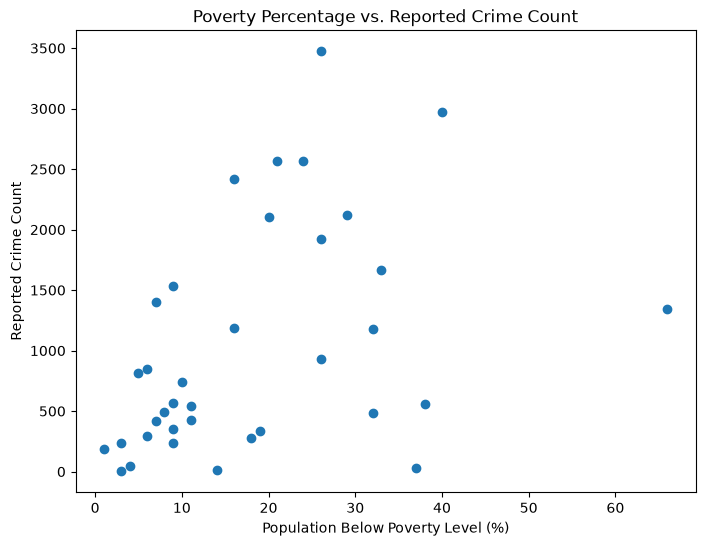

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["Populationbelowpovertylevel"],
    analysis_df["Crime_Count"]
)

plt.xlabel("Population Below Poverty Level (%)")
plt.ylabel("Reported Crime Count")
plt.title("Poverty Percentage vs. Reported Crime Count")

plt.show()

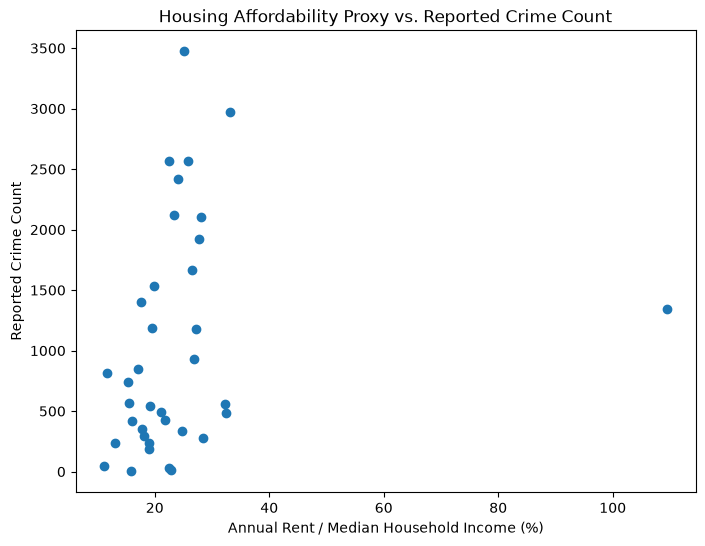

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["Rent_to_Income_Pct"],
    analysis_df["Crime_Count"]
)

plt.xlabel("Annual Rent / Median Household Income (%)")
plt.ylabel("Reported Crime Count")
plt.title("Housing Affordability Proxy vs. Reported Crime Count")

plt.show()

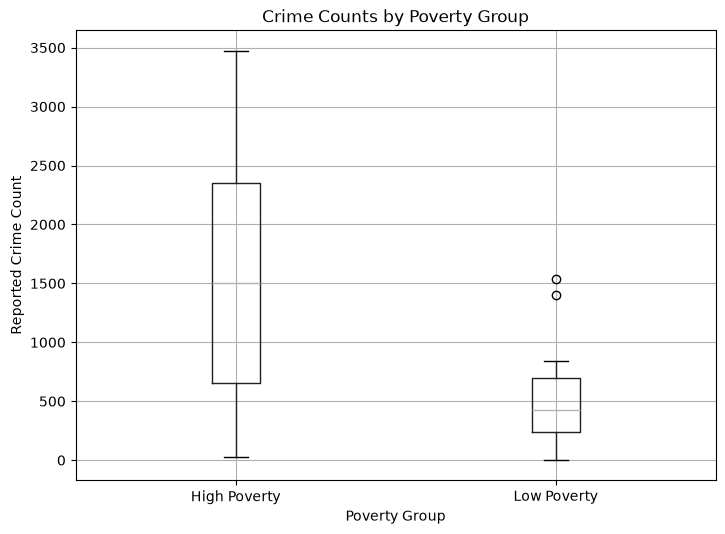

In [22]:
analysis_df.boxplot(
    column="Crime_Count",
    by="Poverty_Group",
    figsize=(8, 6)
)

plt.title("Crime Counts by Poverty Group")
plt.suptitle("")
plt.xlabel("Poverty Group")
plt.ylabel("Reported Crime Count")

plt.show()

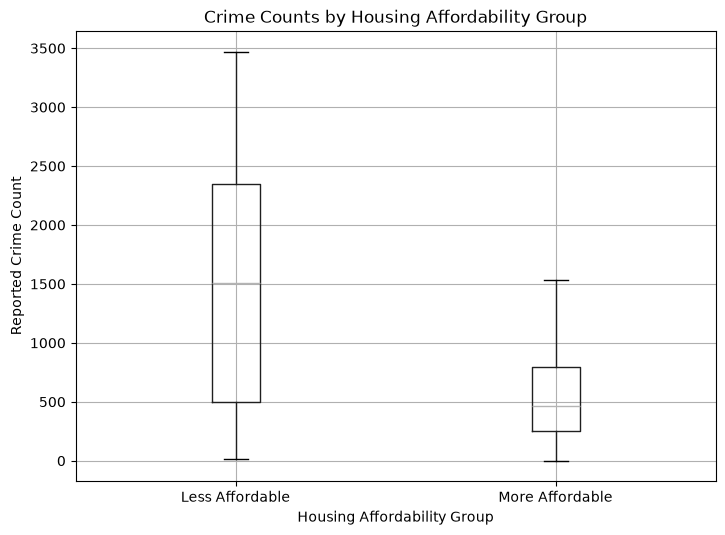

In [23]:
analysis_df.boxplot(
    column="Crime_Count",
    by="Affordability_Group",
    figsize=(8, 6)
)

plt.title("Crime Counts by Housing Affordability Group")
plt.suptitle("")
plt.xlabel("Housing Affordability Group")
plt.ylabel("Reported Crime Count")

plt.show()

In [24]:
results = pd.DataFrame({
    "Analysis": [
        "Poverty vs. Crime",
        "Housing Affordability vs. Crime"
    ],
    "Pearson_r": [
        r_poverty,
        r_affordability
    ],
    "Pearson_p": [
        p_poverty,
        p_affordability
    ],
    "T_statistic": [
        t_poverty,
        t_affordability
    ],
    "T_test_p": [
        p_t_poverty,
        p_t_affordability
    ]
})

results

,Analysis,Pearson_r,Pearson_p,T_statistic,T_test_p
0,Poverty vs. Crime,0.411416,0.012671,4.052122,0.000496
1,Housing Affordability vs. Crime,0.210775,0.217227,3.367902,0.002710
